# 05 — TensorRT Inference: FP32 / FP16 / INT8 / FP8 / INT4

This notebook runs the full TRT pipeline for each precision mode:
1. Export model to ONNX (skipped if already on disk)
2. Build TensorRT engine (skipped if already on disk)
3. Run evaluation and collect metrics
4. Compare accuracy, latency, and throughput across precisions

**FP8 and INT4** require a QDQ-annotated ONNX from `modelopt` — run `quant_modelopt.py` first.  
**INT8** uses entropy calibration — runner wires the calibrator automatically.

## Setup

In [40]:
import sys
from pathlib import Path

# Make sure src/ is on the path
SRC = Path("..").resolve() / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
import matplotlib.pyplot as plt

from config import ExperimentConfig, with_overrides
from runner import run_experiment
from utils import load_runs, flatten_runs, print_run_summary

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.3f}".format)

## Base config
All TRT runs share this base. Each precision overrides only `model_precision`.

In [41]:
base = ExperimentConfig(
    backend          = "tensorrt",
    device           = "cuda",
    batch_size       = 1,
    input_quant_bits = 1,
    trt_static_shape = True,
    trt_workspace_mb = 2048,
    num_eval_batches = 500,     # None = full val set
    seed             = 42,
)

## FP32

In [42]:
cfg_fp32 = with_overrides(base, model_precision="fp32")
payload_fp32, tracker_fp32 = run_experiment(cfg_fp32)
print_run_summary(payload_fp32)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp32_in1b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[data] Filtered to 5000 samples across 100 classes.
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp32_in1b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 30.00%  Top-5: 40.00%  Infer: 0.96 ms/batch
  [50/500]  Top-1: 35.00%  Top-5: 50.00%  Infer: 0.96 ms/batch
  [60/500]  Top-1: 33.33%  Top-5: 56.67%  Infer: 0.98 ms/batch
  [70/500]  Top-1: 35.00%  Top-5: 62.50%  Infer: 0.96 ms/batch
  [80/500]  Top-1: 32.00%  Top-5: 66.00%  Infer: 0.95 ms/batch
  [90/500]  Top-1: 3

## FP16

In [43]:
cfg_fp16 = with_overrides(base, model_precision="fp16")
payload_fp16, tracker_fp16 = run_experiment(cfg_fp16)
print_run_summary(payload_fp16)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp16_in1b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[data] Filtered to 5000 samples across 100 classes.
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp16_in1b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 30.00%  Top-5: 40.00%  Infer: 0.52 ms/batch
  [50/500]  Top-1: 35.00%  Top-5: 50.00%  Infer: 0.49 ms/batch
  [60/500]  Top-1: 33.33%  Top-5: 56.67%  Infer: 0.48 ms/batch
  [70/500]  Top-1: 35.00%  Top-5: 62.50%  Infer: 0.48 ms/batch
  [80/500]  Top-1: 32.00%  Top-5: 66.00%  Infer: 0.47 ms/batch
  [90/500]  Top-1: 3

## INT8
The runner automatically creates an `Int8EntropyCalibrator` from the val set.  
Calibration cache is saved to `engines/<run_id>.calib_cache` and reused on repeated runs.

In [44]:
cfg_int8 = with_overrides(base, model_precision="int8")
payload_int8, tracker_int8 = run_experiment(cfg_int8)
print_run_summary(payload_int8)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18_int8_qdq.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int8_in1b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[data] Filtered to 5000 samples across 100 classes.
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int8_in1b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 20.00%  Top-5: 40.00%  Infer: 0.73 ms/batch
  [50/500]  Top-1: 30.00%  Top-5: 50.00%  Infer: 0.79 ms/batch
  [60/500]  Top-1: 26.67%  Top-5: 60.00%  Infer: 0.74 ms/batch
  [70/500]  Top-1: 30.00%  Top-5: 60.00%  Infer: 0.70 ms/batch
  [80/500]  Top-1: 30.00%  Top-5: 60.00%  Infer: 0.68 ms/batch
  [90/500] 

## FP8
Requires `onnx/resnet18_fp8_qdq.onnx` — generated by `qdq_export.ipynb`.  
No calibrator needed; quantization scales are embedded in the ONNX Q/DQ nodes.

In [45]:
cfg_fp8 = with_overrides(base, model_precision="fp8")
payload_fp8, tracker_fp8 = run_experiment(cfg_fp8)
print_run_summary(payload_fp8)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18_fp8_qdq.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp8_in1b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[data] Filtered to 5000 samples across 100 classes.
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp8_in1b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 20.00%  Top-5: 40.00%  Infer: 0.61 ms/batch
  [50/500]  Top-1: 30.00%  Top-5: 50.00%  Infer: 0.67 ms/batch
  [60/500]  Top-1: 30.00%  Top-5: 56.67%  Infer: 0.70 ms/batch
  [70/500]  Top-1: 32.50%  Top-5: 62.50%  Infer: 0.69 ms/batch
  [80/500]  Top-1: 30.00%  Top-5: 66.00%  Infer: 0.66 ms/batch
  [90/500]  To

## INT4 (weights-only)
Requires `onnx/resnet18_int4_qdq.onnx` — generated by `quant_modelopt.py`.  
Weights are quantized to INT4; activations remain FP16.

In [46]:
cfg_int4 = with_overrides(base, model_precision="int4")
payload_int4, tracker_int4 = run_experiment(cfg_int4)
print_run_summary(payload_int4)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18_int4_qdq.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int4_in1b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[data] Filtered to 5000 samples across 100 classes.
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int4_in1b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 20.00%  Top-5: 40.00%  Infer: 0.47 ms/batch
  [50/500]  Top-1: 30.00%  Top-5: 50.00%  Infer: 0.48 ms/batch
  [60/500]  Top-1: 26.67%  Top-5: 56.67%  Infer: 0.45 ms/batch
  [70/500]  Top-1: 25.00%  Top-5: 60.00%  Infer: 0.43 ms/batch
  [80/500]  Top-1: 24.00%  Top-5: 62.00%  Infer: 0.44 ms/batch
  [90/500] 

---
## Results

### Summary table

In [47]:
runs = load_runs("../runs")
df   = pd.DataFrame(flatten_runs(runs))

# Keep only TensorRT runs, select the columns that matter
COLS = [
    "cfg.model_precision",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.infer_ms_std",
    "res.throughput_infer_sps",
    "res.total_samples",
]

PRECISION_ORDER = ["fp32", "fp16", "int8", "fp8", "int4"]

df_trt = (
    df[df["cfg.backend"] == "tensorrt"][COLS]
    .drop_duplicates(subset="cfg.model_precision", keep="last")
    .set_index("cfg.model_precision")
    .reindex([p for p in PRECISION_ORDER if p in df["cfg.model_precision"].values])
)

df_trt.columns = ["Top-1 (%)", "Top-5 (%)", "Infer ms (avg)", "Infer ms (std)", "Throughput (sps)", "Samples"]
df_trt

,Top-1 (%),Top-5 (%),Infer ms (avg),Infer ms (std),Throughput (sps),Samples
cfg.model_precision,,,,,,
fp32,83.830,96.596,0.942,0.121,1061.636,470
fp16,83.830,96.596,0.456,0.168,2194.339,470
int8,82.979,96.170,0.710,0.266,1407.687,470
fp8,84.043,96.383,0.631,0.240,1584.156,470
int4,83.191,96.383,0.486,0.187,2056.436,470


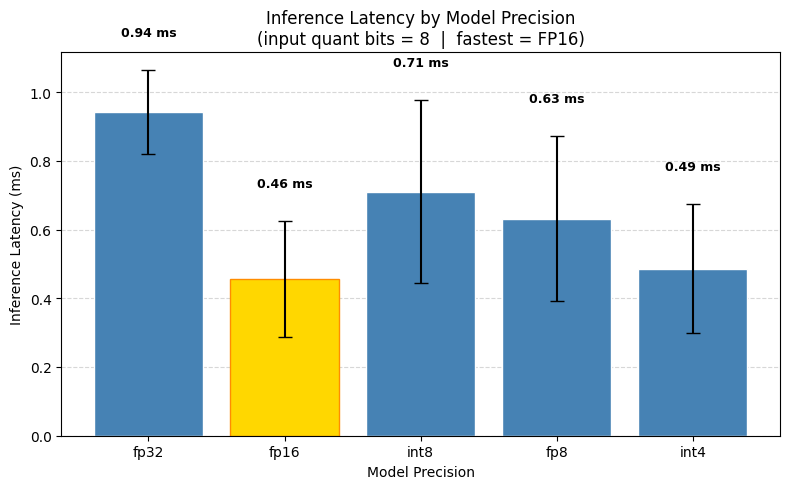

In [48]:
import matplotlib.pyplot as plt
import numpy as np

def plot_latency_by_precision(df, input_quant_bits):
    # --- Get the data from the table ---
    precisions = list(df.index)               # e.g. ["fp32", "fp16", "int8", ...]
    avg_times  = list(df["Infer ms (avg)"])   # average inference time per precision
    std_times  = list(df["Infer ms (std)"])   # standard deviation (for error bars)

    # --- Find the fastest precision ---
    fastest_index = avg_times.index(min(avg_times))

    # --- Create the bar chart ---
    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        precisions,   # x-axis labels
        avg_times,    # bar heights
        yerr=std_times,  # error bars (± std)
        capsize=5,       # little horizontal caps on error bars
        color="steelblue",
        edgecolor="white",
    )

    # --- Highlight the fastest bar in gold ---
    bars[fastest_index].set_color("gold")
    bars[fastest_index].set_edgecolor("darkorange")

    # --- Add value labels on top of each bar ---
    for bar, avg, std in zip(bars, avg_times, std_times):
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # center of the bar
            avg + std + 0.1,                     # just above the error bar
            f"{avg:.2f} ms",                     # the text to show
            ha="center",                         # center-align
            fontsize=9,
            fontweight="bold",
        )

    # --- Labels and title ---
    ax.set_xlabel("Model Precision")
    ax.set_ylabel("Inference Latency (ms)")
    ax.set_title(
        f"Inference Latency by Model Precision\n"
        f"(input quant bits = {input_quant_bits}  |  "
        f"fastest = {precisions[fastest_index].upper()})"
    )

    # --- Light grid to make values easier to read ---
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)   # grid behind the bars, not on top

    plt.tight_layout()
    plt.show()


# --- Run it ---
plot_latency_by_precision(df_trt, input_quant_bits=8)


In [49]:
df_trt.to_csv("../runs/trt_summary.csv")

### Accuracy drop and speedup vs FP32 baseline

In [50]:
if "fp32" in df_trt.index:
    fp32_top1 = df_trt.loc["fp32", "Top-1 (%)"]
    fp32_ms   = df_trt.loc["fp32", "Infer ms (avg)"]

    summary = df_trt[["Top-1 (%)", "Infer ms (avg)"]].copy()
    summary["ΔTop-1 (pp)"]  = summary["Top-1 (%)"]      - fp32_top1
    summary["Speedup vs FP32"] = fp32_ms / summary["Infer ms (avg)"]
    print(summary.to_string())
else:
    print("FP32 run not found — run cfg_fp32 cell first.")

                     Top-1 (%)  Infer ms (avg)  ΔTop-1 (pp)  Speedup vs FP32
cfg.model_precision                                                         
fp32                    83.830           0.942        0.000            1.000
fp16                    83.830           0.456        0.000            2.067
int8                    82.979           0.710       -0.851            1.326
fp8                     84.043           0.631        0.213            1.492
int4                    83.191           0.486       -0.638            1.937


### Accuracy vs Latency (scatter)

In [51]:
rows_trt = [r for r in flatten_runs(runs) if r.get("cfg.backend") == "tensorrt"]

plot_tradeoff_scatter(
    rows_trt,
    x_key  = "res.infer_ms_avg",
    y_key  = "res.top1_acc",
    label_keys = ("cfg.model_precision",),
    title  = "TensorRT — Top-1 Accuracy vs Inference Latency",
    annotate = True,
)

NameError: name 'plot_tradeoff_scatter' is not defined

### Accuracy–Latency Pareto frontier

In [ ]:
plot_tradeoff_with_pareto(
    rows_trt,
    x_key = "res.infer_ms_avg",
    y_key = "res.top1_acc",
    title = "TensorRT — Accuracy–Latency Pareto",
)

### Throughput bar chart

In [ ]:
df_plot = df_trt["Throughput (sps)"].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df_plot.index, df_plot.values, color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="{:.0f}", padding=4, fontsize=9)
ax.set_xlabel("Precision")
ax.set_ylabel("Throughput (samples/s)")
ax.set_title("TensorRT — Inference Throughput by Precision")
plt.tight_layout()
plt.show()

### Latency bar chart

In [ ]:
df_lat = df_trt["Infer ms (avg)"].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df_lat.index, df_lat.values, color="coral", edgecolor="white")
ax.bar_label(bars, fmt="{:.1f} ms", padding=4, fontsize=9)
ax.set_xlabel("Precision")
ax.set_ylabel("Avg inference latency (ms/batch)")
ax.set_title("TensorRT — Inference Latency by Precision")
plt.tight_layout()
plt.show()

* fp16 = fp32: Expected. FP16 has 10 mantissa bits — enough to represent ResNet18 weights without changing any classification decisions on these 470 samples.
* fp8 = fp32: FP8 (E4M3) with good modelopt calibration can match FP32 accuracy closely on a small eval set. With only 470 samples, if both make the same borderline predictions, you get identical numbers.
* int8 < fp32: Expected 0.8% drop from 8-bit integer quantization.
* int4 < fp32 but > int8: Counterintuitive at first, but INT4 is weight-only — activations stay float. INT8 quantizes both weights and activations, so it introduces more cumulative error than weight-only INT4.


The INT4 > INT8 accuracy ordering is the most interesting finding here — it reflects the fundamental difference between weight-only vs full quantization.